In [60]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium 
import contextily as ctx
from matplotlib.patches import Patch
from shapely.geometry import box
import os
import sys
from matplotlib.ticker import ScalarFormatter, MaxNLocator
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from shapely.geometry import Point
import matplotlib.colors as mcolors

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)
# import functions_national as inv_natl

import functions_general as fxns
import functions_preprocessing as pre 
import functions_disagreement_and_gaps as resolve

In [61]:
# Figure Directory 
fig_dir = './Figures/Inventory_Comparison/'
os.makedirs(fig_dir, exist_ok=True)

# Specify resolution of images 
dpi = 330

In [62]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]

# Define the color palette
stanford_palette = [
    "#034185", 
    "#a14059",  
    "#277b8eff",  
    "#ace1fbff",    
    "#a7a7d6ff",
    "#f6c85f", # Yellow
    "#c27ba0"] # Rose

# Set the palette in seaborn
sns.set_palette(sns.color_palette(stanford_palette))
colors = stanford_palette
# Set the palette in seaborn
sns.set_palette(sns.color_palette(stanford_palette))
colors = stanford_palette

### INVENTORY OVERVIEW

In [ ]:
# Define inventories

point26 = fxns.json_to_gdf('./R2D_Analysis/Inventories/NSI_Point/R2D_Inventory.json', crs_main)
national26 = fxns.json_to_gdf('./R2D_Analysis/Inventories/Synthesized_National/R2D_Inventory.json', crs_main)
best26 = fxns.json_to_gdf('./R2D_Analysis/Inventories/Best_Estimate/R2D_Inventory.json', crs_main)
point22 = fxns.json_to_gdf('./R2D_Analysis/Inventories/NSI22_Point/R2D_Inventory.json', crs_main)

# Footprints
footprints = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)


In [ ]:
inventories = [point22, point26, national26, best26]
inventory_names = ['NSI Points 2022', 'NSI Points 2026', 'Synthesized National 2026', 'Best Estimate 2026']

# Set inventory lengths
inventory_lengths = [len(gdf) for gdf in inventories]

# Set population values 
pop_values = [gdf['NightPopulation'].sum() for gdf in inventories]

# Set population values 
pop_day_values = [gdf['DayPopulation'].sum() for gdf in inventories]

# Set values 
structure_values = [gdf['StructureValue'].sum() for gdf in inventories]
structure_and_content_values = [gdf['ReplacementCost'].sum() for gdf in inventories]

structure_values_billions = [v / 10**9 for v in structure_values]
structure_and_content_values_billions = [v / 10**9 for v in structure_and_content_values]


In [ ]:
mapping = {
    'RES1': 1,
    'RES2': 1,
    'RES3A': 2,
    'RES3B': 3.5,
    'RES3C':7.5,
    'RES3D':15,
    'RES3E':35,
    'RES3F':50,
    'RES1M': 1,
    'RES2M': 1,
    'RES3AM': 2,
    'RES3BM': 3.5,
    'RES3CM':7.5,
    'RES3DM':15,
    'RES3EM':35,
    'RES3FM':50,}

mapping_min = {
    'RES1': 1,
    'RES2': 1,
    'RES3A': 2,
    'RES3B': 3,
    'RES3C':5,
    'RES3D':10,
    'RES3E':20,
    'RES3F':50,
    'RES1M': 1,
    'RES2M': 1,
    'RES3AM': 2,
    'RES3BM': 3,
    'RES3CM':5,
    'RES3DM':10,
    'RES3EM':20,
    'RES3FM':50,}

mapping_max = {
    'RES1': 1,
    'RES2': 1,
    'RES3A': 2,
    'RES3B': 4,
    'RES3C':9,
    'RES3D':19,
    'RES3E':50,
    'RES3F':50,
    'RES1M': 1,
    'RES2M': 1,
    'RES3AM': 2,
    'RES3BM': 4,
    'RES3CM':9,
    'RES3DM':19,
    'RES3EM':50,
    'RES3FM':50,
    }


## TOTAL UNITS 




point22['NumberOfUnits']=point22['OccupancyClass_Actual'].map(mapping)
point26['NumberOfUnits']=point26['OccupancyClass_Actual'].map(mapping)

for inventory in inventories: 
    inventory['NumberOfUnits_Min'] = inventory['NumberOfUnits']
    inventory['NumberOfUnits_Max'] = inventory['NumberOfUnits']


point22['NumberOfUnits_Min']=point22['OccupancyClass_Actual'].map(mapping_min)
point26['NumberOfUnits_Min']=point26['OccupancyClass_Actual'].map(mapping_min)


point22['NumberOfUnits_Max']=point22['OccupancyClass_Actual'].map(mapping_max)
point26['NumberOfUnits_Max']=point26['OccupancyClass_Actual'].map(mapping_max)



# Zero out all non-RES units
for inventory in inventories: 
    inventory.loc[~inventory['OccupancyClass_Actual'].str.contains('RES'),'NumberOfUnits'] = 0
    inventory.loc[~inventory['OccupancyClass_Actual'].str.contains('RES'),'NumberOfUnits_Min'] = 0
    inventory.loc[~inventory['OccupancyClass_Actual'].str.contains('RES'),'NumberOfUnits_Max'] = 0
   


total_units=[]
min_units = []
max_units = []

for inventory in inventories: 

    res = inventory[inventory['OccupancyClass_Actual'].str.contains('RES1|RES2|RES3')]
    total_units.append(res['NumberOfUnits'].sum())
    min_units.append(res['NumberOfUnits_Min'].sum())
    max_units.append(res['NumberOfUnits_Max'].sum())
    # print(total_units)

In [ ]:
fig, ax = plt.subplots(1,5, figsize = (20,6))


# NUMBER BUILDINGS
ax[0].bar(inventory_names, inventory_lengths, color = colors[0])
ax[0].set_title('Number of Buildings per Inventory')
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].set_ylabel('Number of Buildings')


# NUMBER UNITS
ax[1].bar(inventory_names,max_units,color=colors[2],alpha=0.4,label='Max Number of Units')
ax[1].bar(inventory_names,min_units,color=colors[2],label='Min Number of Units')
ax[1].set_title('Number of Residential Units per Inventory')
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].axhline(y = 52268, linestyle = '--', linewidth = 2, color = 'black', label= '2020 Census')
ax[1].legend(loc = 'upper left', fontsize = 10)
ax[1].set_ylim(0, 90000)
ax[1].set_ylabel('Number of Units')

# NUMBER PEOPLE NIGHT
ax[2].bar(inventory_names, pop_values, color = colors[1])
ax[2].set_title('Nighttime Population per Inventory')
ax[2].tick_params(axis='x', labelrotation=45)
ax[2].axhline(y = 162954, linestyle = '--', linewidth = 2, color = 'black', label= '2020 Census')
ax[2].legend(loc = 'upper left', fontsize = 10)
ax[2].set_ylim(0, 190000)
ax[2].set_ylabel('Nighttime Population')

# NUMBER PEOPLE DAY
ax[3].bar(inventory_names, pop_day_values, color = colors[1])
ax[3].set_title('Daytime Population per Inventory')
ax[3].tick_params(axis='x', labelrotation=45)
ax[3].axhline(y = 162954, linestyle = '--', linewidth = 2, color = 'black', label= '2020 Census')
ax[3].legend(loc = 'upper left', fontsize = 10)
ax[3].set_ylim(0, 190000)
ax[3].set_ylabel('Daytime Population')

# TOTAL STRUCTURE VALUE 
ax[4].bar(inventory_names, structure_and_content_values_billions, alpha=0.4, color = colors[5],label='Content Value')
ax[4].bar(inventory_names, structure_values_billions, color = colors[5],label='Structure Value')
ax[4].set_title('Total Value per Inventory (Billions of Dollars)')
ax[4].tick_params(axis='x', labelrotation=45)
ax[4].set_ylabel('Total Value (Billions of Dollars)')
ax[4].legend(loc = 'upper left', fontsize = 10)
ax[4].set_ylim(0, 80)



plt.tight_layout()
plt.show()

### SPECIFIC OCCUPANCY CLASSES

In [ ]:
bb1 = box(-122.091084,37.636168,-122.081788,37.648756)



occ = 'RES2'


fig, ax = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True, dpi=dpi)


for i, inventory in enumerate(inventories): 

    # Footprints 
    footprints.to_crs(crs_plot).plot(ax=ax[i], color = 'gray', alpha = 0.5)

    # Plot occupancy 
    inventory[inventory['OccupancyClass_Actual'].str.contains(occ)].plot(ax = ax[i], color = 'tab:red', markersize = 1, label = occ)

    # # Basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)
    gdf_bb = gpd.GeoDataFrame({"geometry": [bb1]}, crs=crs_plot)
    gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)

    ax[i].legend(loc = 'upper left')

ax[0].set_xticks([])
ax[0].set_yticks([])

plt.xlim(xbounds)
plt.ylim(ybounds)
plt.tight_layout()


In [ ]:
bb1 = box(-122.091084,37.636168,-122.081788,37.648756)



occ = 'RES3F'


fig, ax = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True, dpi=dpi)


for i, inventory in enumerate(inventories): 

    # Footprints 
    footprints.to_crs(crs_plot).plot(ax=ax[i], color = 'gray', alpha = 0.5)

    # Plot occupancy 
    inventory[inventory['OccupancyClass_Actual'].str.contains(occ)].plot(ax = ax[i], color = colors[6], markersize = 30, label = occ)

    # # Basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)
    gdf_bb = gpd.GeoDataFrame({"geometry": [bb1]}, crs=crs_plot)
    gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)

    ax[i].legend(loc = 'upper left')

ax[0].set_xticks([])
ax[0].set_yticks([])

plt.xlim(xbounds)
plt.ylim(ybounds)
plt.tight_layout()


In [ ]:
bb1 = box(-122.091084,37.636168,-122.081788,37.648756)



occ = 'GOV1'


fig, ax = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True, dpi=dpi)


for i, inventory in enumerate(inventories): 

    # Footprints 
    footprints.to_crs(crs_plot).plot(ax=ax[i], color = 'gray', alpha = 0.5)

    # Plot occupancy 
    inventory[inventory['OccupancyClass_Actual'].str.contains(occ)].plot(ax = ax[i], color = colors[2], markersize = 10, label = occ)

    # # Basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)
    gdf_bb = gpd.GeoDataFrame({"geometry": [bb1]}, crs=crs_plot)
    gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)

    ax[i].legend(loc = 'upper left')

ax[0].set_xticks([])
ax[0].set_yticks([])

plt.xlim(xbounds)
plt.ylim(ybounds)
plt.tight_layout()


In [ ]:
bb1 = box(-122.091084,37.636168,-122.081788,37.648756)



occ = 'GOV2'


fig, ax = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True, dpi=dpi)


for i, inventory in enumerate(inventories): 

    # Footprints 
    footprints.to_crs(crs_plot).plot(ax=ax[i], color = 'gray', alpha = 0.5)

    # Plot occupancy 
    inventory[inventory['OccupancyClass_Actual'].str.contains(occ)].plot(ax = ax[i], color = colors[1], markersize = 50, label = occ)

    # # Basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)
    gdf_bb = gpd.GeoDataFrame({"geometry": [bb1]}, crs=crs_plot)
    gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)

    ax[i].legend(loc = 'upper left')

ax[0].set_xticks([])
ax[0].set_yticks([])

plt.xlim(xbounds)
plt.ylim(ybounds)
plt.tight_layout()


In [ ]:
bb1 = box(-122.091084,37.636168,-122.081788,37.648756)



occ = 'GOV2'


fig, ax = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True, dpi=dpi)


for i, inventory in enumerate(inventories): 

    # Footprints 
    footprints.to_crs(crs_plot).plot(ax=ax[i], color = 'gray', alpha = 0.5)

    # Plot occupancy 
    inventory[inventory['OccupancyClass_Actual'].str.contains("EDU1")].plot(ax = ax[i], color = colors[0], markersize = 40, label = occ, alpha = 1)
    inventory[inventory['OccupancyClass_Actual'].str.contains("EDU2")].plot(ax = ax[i], color = colors[4], markersize = 40, label = occ, alpha = 0.5)
    # inventory[inventory['OccupancyClass_Actual'].str.contains("EDU1")].plot(ax = ax[i], color = colors[0], markersize = 10, label = occ)

    # # Basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)
    gdf_bb = gpd.GeoDataFrame({"geometry": [bb1]}, crs=crs_plot)
    gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)

    ax[i].legend(loc = 'upper left')

ax[0].set_xticks([])
ax[0].set_yticks([])

plt.xlim(xbounds)
plt.ylim(ybounds)
plt.tight_layout()


### DAMAGE AND LOSS

In [63]:
# NSI 2026 BEST ESTIMATE
best26 = gpd.read_file('./R2D_Analysis/Inventories/Best_Estimate/Results.csv')
geometry = [Point(xy) for xy in zip(best26['Longitude'], best26['Latitude'])]
best26 = gpd.GeoDataFrame(best26, geometry=geometry, crs=crs_plot)

# NSI 2025 SYNTHESIZED NATIONAL 
national26 = gpd.read_file('./R2D_Analysis/Inventories/Synthesized_National/Results.csv')
geometry = [Point(xy) for xy in zip(national26['Longitude'], national26['Latitude'])]
national26 = gpd.GeoDataFrame(national26, geometry=geometry, crs=crs_plot)

# NSI 2026 POINT INVENTORY
raw26 = gpd.read_file('./R2D_Analysis/Inventories/NSI_Point/Results.csv')
geometry = [Point(xy) for xy in zip(raw26['Longitude'], raw26['Latitude'])]
raw26 = gpd.GeoDataFrame(raw26, geometry=geometry, crs=crs_plot)

# NSI 2022 POINT INVENTORY
raw22 = gpd.read_file('./R2D_Analysis/Inventories/NSI22_Point/Results.csv')
geometry = [Point(xy) for xy in zip(raw22['Longitude'], raw22['Latitude'])]
raw22 = gpd.GeoDataFrame(raw22, geometry=geometry, crs=crs_plot)


raw22['DV'] = raw22['DV'].astype(float)
raw26['DV'] = raw26['DV'].astype(float)
national26['DV'] = national26['DV'].astype(float)
best26['DV'] = best26['DV'].astype(float)


raw22['ReplacementCost'] = raw22['ReplacementCost'].astype(float)
raw26['ReplacementCost'] = raw26['ReplacementCost'].astype(float)
national26['ReplacementCost'] = national26['ReplacementCost'].astype(float)
best26['ReplacementCost'] = best26['ReplacementCost'].astype(float)



inventories = [raw22, raw26, national26, best26]
inventory_names = ['NSI Points 2022', 'NSI Points 2026', 'Synthesized National 2026', 'Best Estimate 2026']


In [ ]:
# color_mapping = {
#     '0': '#00008B', #'#00008B',  # Example: No damage
#     '1': '#377EB8',  # Example: Minor damage
#     '2': '#FFB300',  # Example: Moderate damage
#     '3': '#fc7b03', ##E65100',     # Example: Severe damage
#     '4': 'red'   # Example: Critical damage
# }

# # Map the R2Dres_MostLikelyCriticalDamageState column to colors
# best26['color'] = best26['DS'].map(color_mapping)
# best26['color'] = best26['color'].fillna('black') 
# national26['color'] = national26['DS'].map(color_mapping)
# national26['color'] = national26['color'].fillna('black') 
# raw26['color'] = raw26['DS'].map(color_mapping)
# raw26['color'] = raw26['color'].fillna('black') 
# raw22['color'] = raw22['DS'].map(color_mapping)
# raw22['color'] = raw22['color'].fillna('black') 

# # Create figure
# fig, ax = plt.subplots(1,4, figsize = (16,5), sharex = True, sharey = True, dpi = dpi)

# # Plot damage state 
# raw22.plot(ax=ax[0], markersize=0.1, legend=True, color=raw22['color'].tolist())
# raw26.plot(ax=ax[1], markersize=0.1, legend=True, color=raw26['color'].tolist())
# national26.to_crs('EPSG:4326').plot(ax=ax[2], markersize=0.1, legend=True, color=national26['color'].tolist())
# best26.to_crs('EPSG:4326').plot(ax=ax[3], markersize=0.1, legend=True, color=best26['color'].tolist())

# # Plot tile 
# ax[0].set_title('NSI22 Point Inventory')
# ax[1].set_title('NSI26 Point Inventory')
# ax[2].set_title('Synthesized National Inventory (Using NSI26 Data)')
# ax[3].set_title('Best Estimate Inventory (Using NSI26 Data)')


# # Create legend 
# legend_elements = [
#     Patch(facecolor=color, label=f'Damage State {state}')
#     for state, color in color_mapping.items()]
# ax[0].legend(handles=legend_elements, loc='upper left', fontsize = 9)

# # Add basemap
# for i in range(4):

#     # Add the OpenStreetMap basemap
#     ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

#     # Add (transparent) box to reduce distortion
#     bb = box(-122.091127,37.636333,-122.080399,37.643282)
#     gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
#     gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=2, alpha = 0)


# plt.xlim(xbounds)
# plt.ylim(ybounds)

# # # Show the plot
# # plt.tight_layout()
# # plt.savefig(fig_dir + "ds_mode.svg", format="svg",  bbox_inches='tight', pad_inches=0)
# # plt.savefig(fig_dir + "ds_mode.png", bbox_inches='tight', pad_inches=0)
# # plt.close()


In [ ]:
# Bounding boxes
bb1 = box(-122.091084,37.636168,-122.081788,37.648756)
bb2 = box(-122.07904,37.617225,-122.053395,37.633955)
bb3 = box(-122.048849,37.607133,-122.025268,37.627867)
# bb4 = box(-122.0973952533,37.6634643972,-122.070318018,37.6783167938)
bb4 = box(-122.0919168413,37.665593478,-122.0697363139,37.6801923058)

# Set max and min 
vmin  = 0
vmax = 0.7
cmap = "RdYlBu_r" 


fig, ax = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
raw22.plot(column='DV', cmap=cmap, ax=ax[0], legend=False, vmin=vmin, vmax=vmax, markersize=0.1)
raw26.plot(column='DV', cmap=cmap, ax=ax[1], legend=False, vmin=vmin, vmax=vmax, markersize=0.1)
national26.plot(column='DV', cmap=cmap, ax=ax[2], legend=False, vmin=vmin, vmax=vmax, markersize=0.1)
best26.plot(column='DV', cmap=cmap, ax=ax[3], legend=False, vmin=vmin, vmax=vmax, markersize=0.1)



# Add basemap
for i in range(4):

    # Add the OpenStreetMap basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

    # Add boxes to point out features
    for bb in [bb1, bb2, bb3, bb4]:
        gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
        gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 1)

# Plot tile 
ax[0].set_title('NSI22 Point Inventory', fontsize = 14)
ax[1].set_title('NSI26 Point Inventory', fontsize = 14)
ax[2].set_title('Synthesized National Inventory (using NSI26)', fontsize = 14)
ax[3].set_title('Best Estimate Inventory (using NSI26)', fontsize = 14)

# Set tick marks for x axis 
# ax[0].xaxis.set_major_locator(MaxNLocator(nbins=3))
# ax[0].yaxis.set_major_locator(MaxNLocator(nbins=3))

ax[0].set_xticks([])
ax[0].set_yticks([])

plt.xlim(xbounds)
plt.ylim(ybounds)
plt.tight_layout()


# Add a single colorbar for all subplots
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  # Necessary for ScalarMappable
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Mean Loss Ratio', fontsize = 12)



plt.savefig(fig_dir + "loss_ratio.svg", format="svg",  bbox_inches='tight', pad_inches=0)
plt.savefig(fig_dir + "loss_ratio.png",  bbox_inches='tight', pad_inches=0)


plt.show()


In [ ]:

# Set max and min 
vmin  = 0
vmax = 0.7
cmap = "RdYlBu_r" 


for bb in [bb1, bb2, bb3, bb4]:


    # Filter data for box bb2
    bb_df = gpd.GeoDataFrame(geometry=[bb], crs=raw26.crs)
    raw22_bb = gpd.sjoin(raw22, bb_df, predicate="intersects")
    raw_bb = gpd.sjoin(raw26, bb_df, predicate="intersects")
    national_bb = gpd.sjoin(national26, bb_df, predicate="intersects")
    best_bb = gpd.sjoin(best26, bb_df, predicate="intersects")


    fig, ax = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True, dpi=dpi)

    # Plot results 
    ms = 4
    raw22_bb.plot(column='DV', cmap=cmap, ax=ax[0], vmin=vmin, vmax=vmax, markersize=ms)
    raw_bb.plot(column='DV', cmap=cmap, ax=ax[1], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
    national_bb.plot(column='DV', cmap=cmap, ax=ax[2], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
    best_bb.plot(column='DV', cmap=cmap, ax=ax[3], legend=False, vmin=vmin, vmax=vmax, markersize=ms)



    # Add basemap
    for i in range(4):

        # Add the OpenStreetMap basemap
        ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)


        # gdf_bb = gpd.GeoDataFrame({"geometry": [bb1]}, crs=crs_plot)
        # gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)

    # Plot tile 
    ax[0].set_title('NSI22 Point Inventory')
    ax[1].set_title('NSI26 Point Inventory')
    ax[2].set_title('Synthesized National Inventory')
    ax[3].set_title('Best Estimate Inventory')

    # Set tick marks for x axis 
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    # plt.xlim(xbounds)
    # plt.ylim(ybounds)

    plt.tight_layout()

    # Add a single colorbar for all subplots
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []  # Necessary for ScalarMappable
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_label('Mean Loss Ratio', fontsize = 12)

    # plt.tight_layout()
    plt.show()

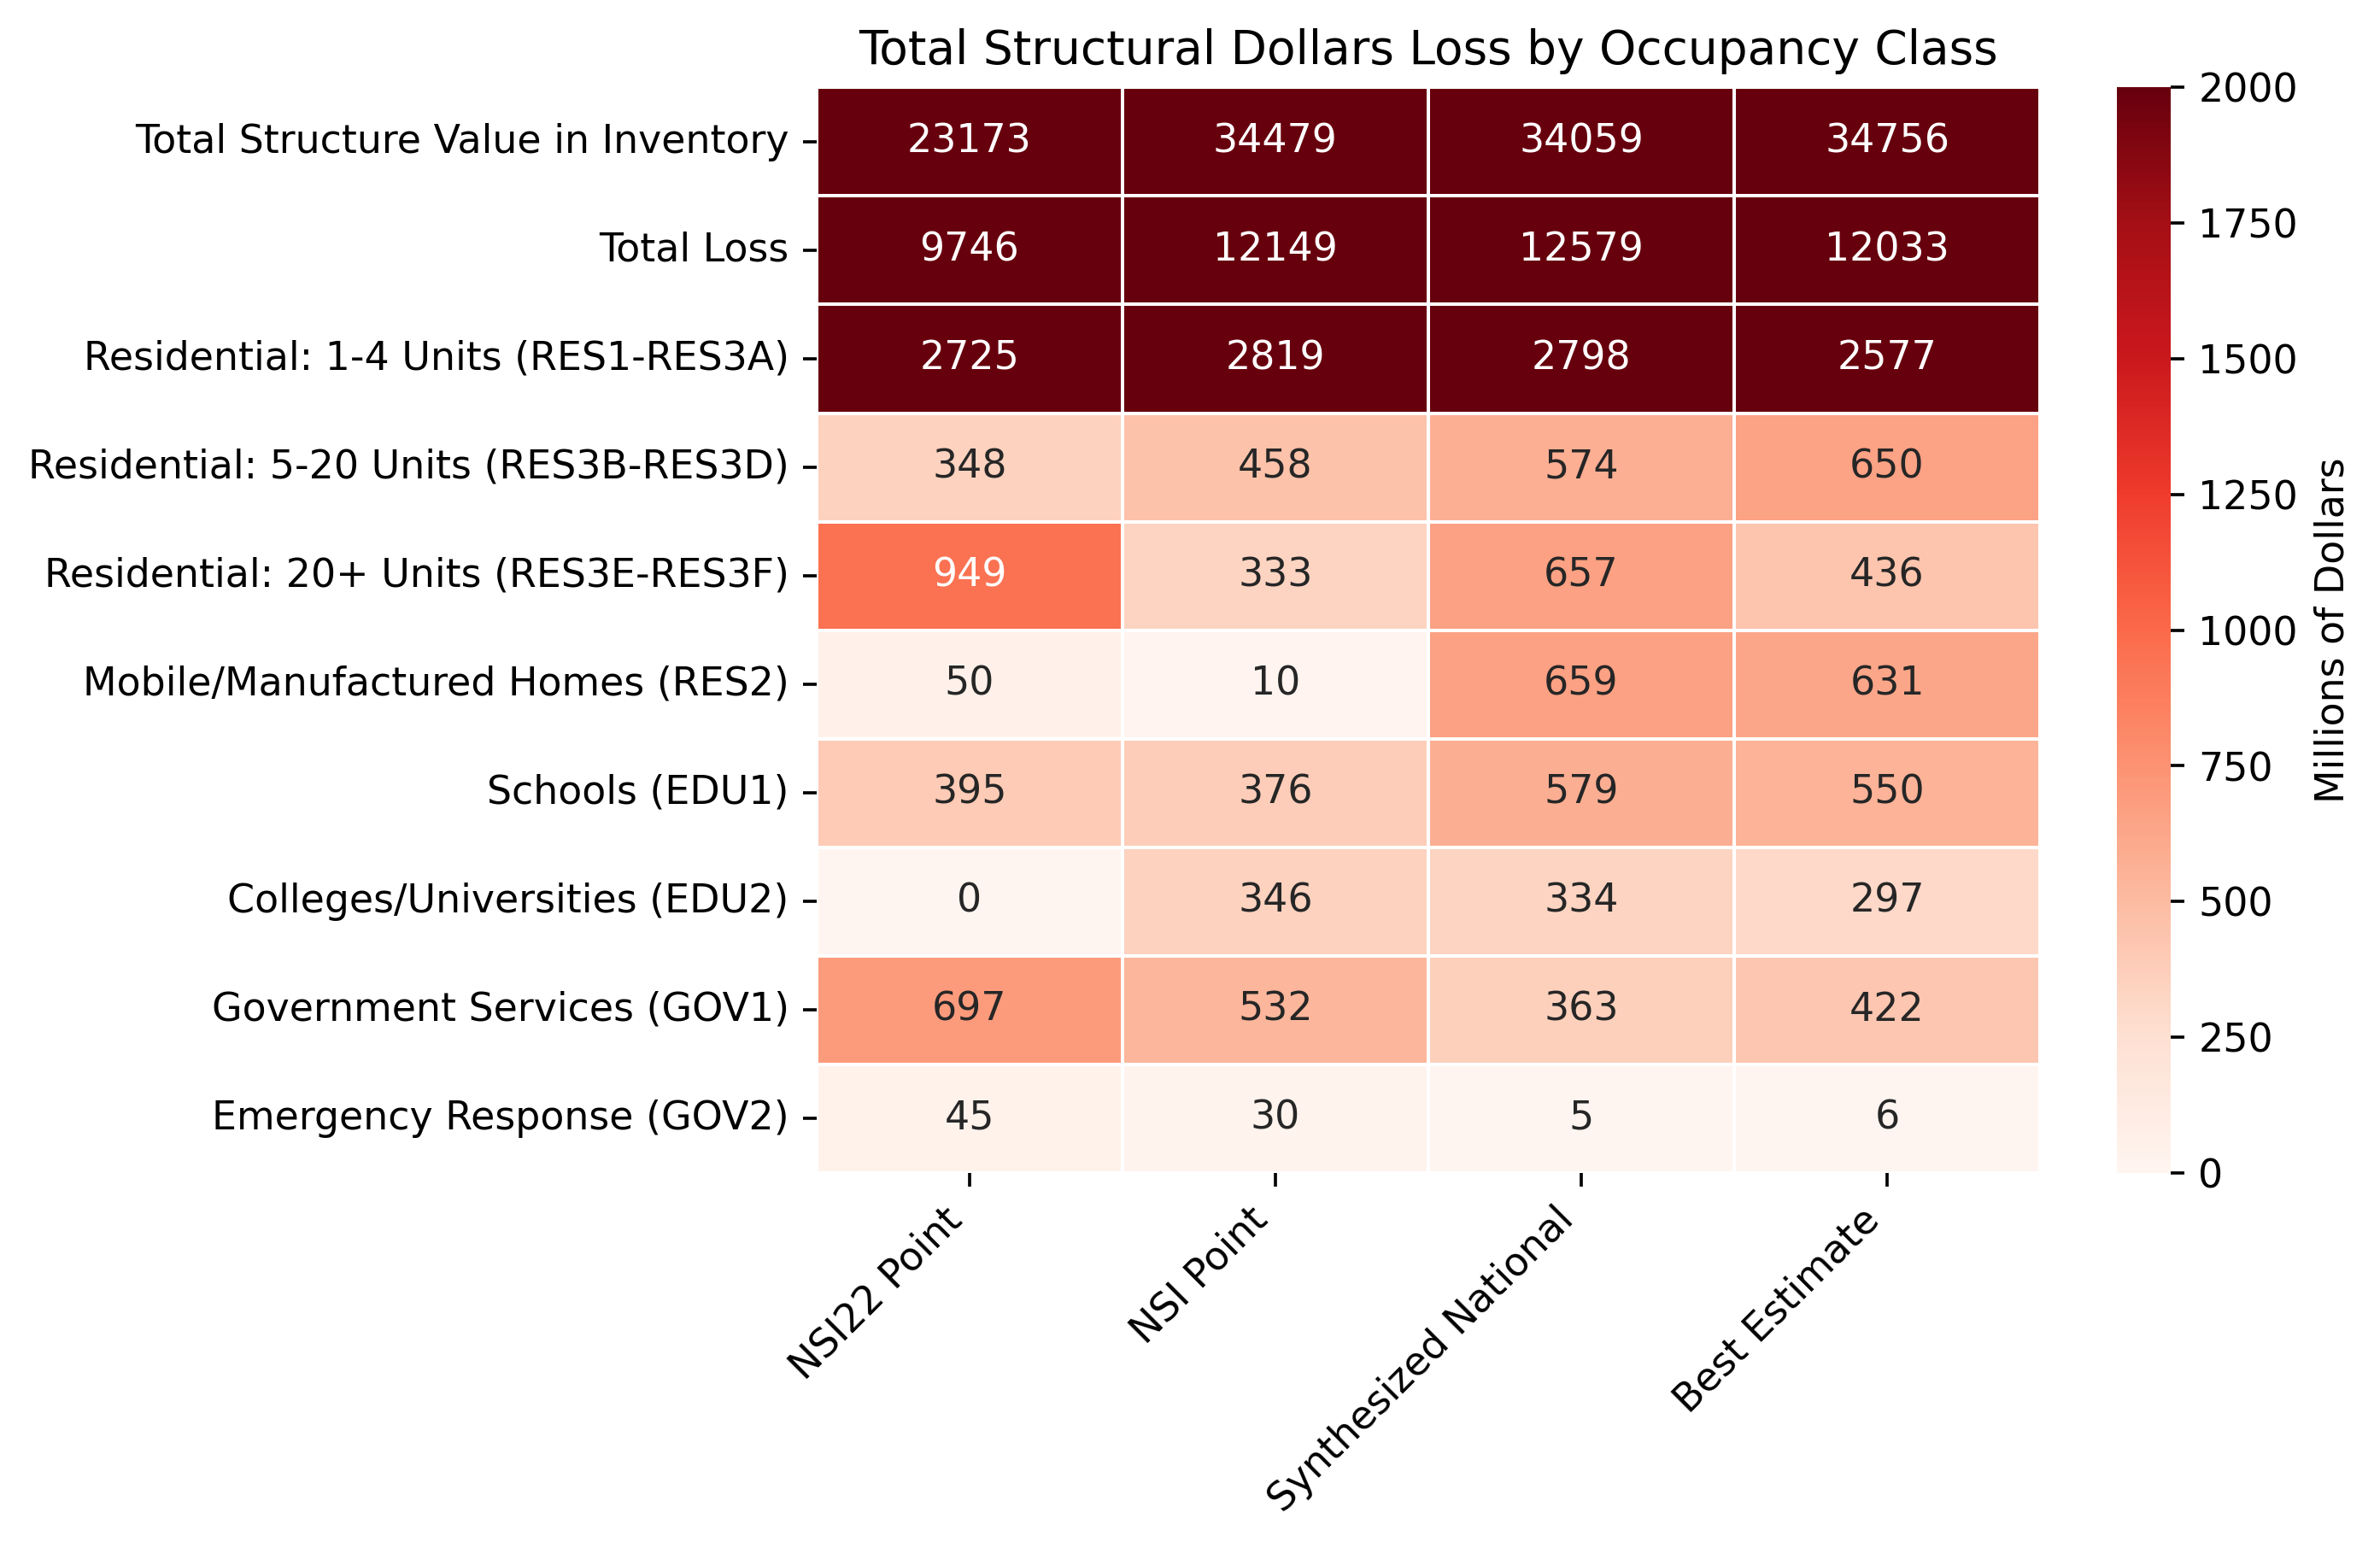

In [64]:
### COLORED PLOT, WITHOUT TOTAL VALUE AND TOTAL LOSS

# Compute dollar loss
raw22['DollarLoss'] = (raw22['DV'])*raw22['ReplacementCost']
raw26['DollarLoss'] = (raw26['DV'])*raw26['ReplacementCost']
national26['DollarLoss'] = (national26['DV'])*national26['ReplacementCost']
best26['DollarLoss'] = (best26['DV'])*best26['ReplacementCost']





national26['OccupancyClass_Simple'] = national26['OccupancyClass_Actual'].apply(resolve.simplify_occ)
best26['OccupancyClass_Simple'] = best26['OccupancyClass_Actual'].apply(resolve.simplify_occ)

raw22['StructureValue'] = pd.to_numeric(raw22['StructureValue'] , errors='coerce')
raw26['StructureValue'] = pd.to_numeric(raw26['StructureValue'] , errors='coerce')
national26['StructureValue'] = pd.to_numeric(national26['StructureValue'] , errors='coerce')
best26['StructureValue'] = pd.to_numeric(best26['StructureValue'] , errors='coerce')



col = 'DollarLoss'

total_dollar_raw22 = []
total_dollar_raw = []
total_dollar_national = []
total_dollar_best = []

replacement_costs_raw22 = []
replacement_costs_raw = []
replacement_costs_nat = []
replacement_costs_best = []


# Append total informaiton 
total_dollar_raw22.append(raw22['StructureValue'].sum())
total_dollar_raw.append(raw26['StructureValue'].sum())
total_dollar_national.append(national26['StructureValue'].sum())
total_dollar_best.append(best26['StructureValue'].sum())

# Append total informaiton 
replacement_costs_raw22.append(raw22['StructureValue'].sum())
replacement_costs_raw.append(raw26['StructureValue'].sum())
replacement_costs_nat.append(national26['StructureValue'].sum())
replacement_costs_best.append(best26['StructureValue'].sum())

# Append total informaiton 
total_dollar_raw22.append(raw22['DollarLoss'].sum())
total_dollar_raw.append(raw26['DollarLoss'].sum())
total_dollar_national.append(national26['DollarLoss'].sum())
total_dollar_best.append(best26['DollarLoss'].sum())

# occs = ['RES1|RES3A', 'RES3B|RES3C|RES3D|RES3E','RES3F','RES2','EDU1','EDU2','GOV1','GOV2']
# labels = ['Total Value in Inventory','Total Loss','Residential: 1-2 Units (RES1-RES3A)', 'Residential: 3-50 Units (RES3B-RES3E)', 'Residential: 50+ Units (RES3F)', 'Mobile/Manufactured Homes (RES2)', 'Schools (EDU1)', 'Colleges/Universities (EDU2)','Government Services (GOV1)', 'Emergency Response (GOV2)']


# occs = ['RES1|RES3A', 'RES3B|RES3C|RES3D','RES3E|RES3F','RES2','EDU1','EDU2','GOV1','GOV2']
# labels = ['Residential: 1-2 Units (RES1-RES3A)', 'Residential: 3-20 Units (RES3B-RES3D)', 'Residential: 20+ Units (RES3E-RES3F)', 'Mobile/Manufactured Homes (RES2)', 'Schools (EDU1)', 'Colleges/Universities (EDU2)','Government Services (GOV1)', 'Emergency Response (GOV2)']



# I THINK MOST LOGICAL? 
occs = ['RES1|RES3A|RES3B', 'RES3C|RES3D','RES3E|RES3F','RES2','EDU1','EDU2','GOV1','GOV2']
labels = ['Total Structure Value in Inventory','Total Loss', 'Residential: 1-4 Units (RES1-RES3A)', 'Residential: 5-20 Units (RES3B-RES3D)', 'Residential: 20+ Units (RES3E-RES3F)', 'Mobile/Manufactured Homes (RES2)', 'Schools (EDU1)', 'Colleges/Universities (EDU2)','Government Services (GOV1)', 'Emergency Response (GOV2)']


# # # USE 1800
# occs = ['RES','RES1','RES3A', 'RES3B','RES3C','RES3D','RES3E','RES3F','RES2','EDU1','EDU2','GOV1','GOV2']
# labels = ['Total Residential Value in Inventory','RES1','RES3A', 'RES3B','RES3C','RES3D','RES3E','RES3F','RES2','EDU1','EDU2','GOV1','GOV2']


# occs = ['RES','IND','COM','GOV','EDU','REL','AGR']
# labels = ['Total Value in Inventory','RES','IND','COM','GOV','EDU','REL','AGR']


for occ in  occs:

    raw22_rows = raw22[raw22['OccupancyClass_Actual'].str.contains(occ)]
    total_dollar_raw22.append(raw22_rows[col].sum())
    replacement_costs_raw22.append(raw22_rows['StructureValue'].sum())

    # Raw 
    raw_rows = raw26[raw26['OccupancyClass_Actual'].str.contains(occ)]
    total_dollar_raw.append(raw_rows[col].sum())
    replacement_costs_raw.append(raw_rows['StructureValue'].sum())

    # National 
    nat_rows = national26[national26['OccupancyClass_Simple'].str.contains(occ)]
    total_dollar_national.append(nat_rows[col].sum())
    replacement_costs_nat.append(nat_rows['StructureValue'].sum())

    # Best 
    best_rows = best26[best26['OccupancyClass_Simple'].str.contains(occ)]
    total_dollar_best.append(best_rows[col].sum())
    replacement_costs_best.append(best_rows['StructureValue'].sum())



# Create dataframes to store data
occ_specific_loss = pd.DataFrame({'NSI22 Point': total_dollar_raw22, 'NSI Point': total_dollar_raw, 'Synthesized National': total_dollar_national, 'Best Estimate': total_dollar_best}) #, index = occs)
occ_specific_replace = pd.DataFrame({'NSI22 Point': replacement_costs_raw22, 'NSI Point': replacement_costs_raw, 'Synthesized National': replacement_costs_nat, 'Best Estimate': replacement_costs_best}) #, index = occs)
occ_specific_loss = occ_specific_loss.fillna(0)
occ_specific_replace = occ_specific_replace.fillna(0)
# occ_specific_loss.to_csv('./Figures/Tables/occ_loss.csv')

# Reformat 
occ_specific_loss.index = labels
# occ_specific_replace.index = labels


# # Create the heatmap of replacement cost
# plt.figure(figsize=(7, 5))
# sns.heatmap(occ_specific_replace / 10**6, annot=True, fmt=".0f",cmap='Reds', linewidths=0.5, cbar=True, vmin=0, vmax=7200, cbar_kws={'label': 'Millions of Dollars'}) #1800, 60000
# plt.title(f'Structure Value ')
# plt.show()

# Create the heatmap of loss
plt.figure(dpi = dpi, figsize=(7, 5))
plt.title(f'Total Structural Dollars Loss by Occupancy Class')
ax = sns.heatmap(occ_specific_loss / 10**6, annot=True, fmt=".0f",cmap='Reds', linewidths=0.5, cbar=True, vmin=0, vmax=2000, cbar_kws={'label': 'Millions of Dollars'}) #1800, 60000
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.show()

# plt.savefig(fig_dir + "loss_heatmap_with_total.svg", format="svg",  bbox_inches='tight', pad_inches=0)
# plt.savefig(fig_dir + "loss_heatmap_with_total.png",  bbox_inches='tight', pad_inches=0)
# plt.close()




### NUMBER OF HIGH DAMAGE UNITS AND BUIDLINGS

In [76]:

res_dam_bldgs = []
res_dam_units = []

raw22['NumberOfUnits']=raw22['OccupancyClass_Actual'].map(mapping)
raw26['NumberOfUnits']=raw26['OccupancyClass_Actual'].map(mapping)


for inventory in inventories:

    inventory['DS'] = pd.to_numeric(inventory['DS'] , errors='coerce')
    inventory['NumberOfUnits'] = pd.to_numeric(inventory['NumberOfUnits'] , errors='coerce')

    res = inventory[inventory['OccupancyClass_Actual'].str.contains('RES1|RES2|RES3')]
    high_dam_res = res[res['DS']>=3]

    res_dam_bldgs.append(len(high_dam_res))
    res_dam_units.append(high_dam_res['NumberOfUnits'].sum())

<Figure size 2112x1584 with 0 Axes>

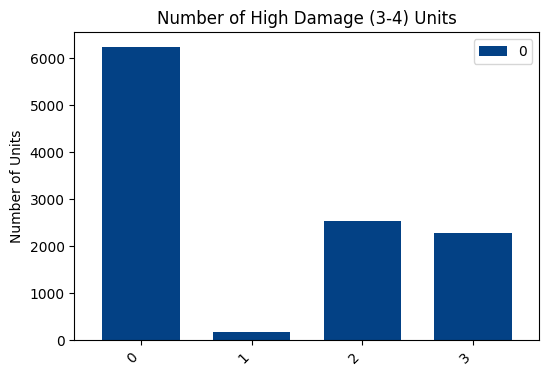

In [77]:

plt.figure(dpi = dpi)
damage_counts = pd.DataFrame(res_dam_bldgs) #, index=inventory_names)
ax = damage_counts.plot(kind='bar', figsize=(6, 4), width=0.7, color = colors)
# ax.set_ylim([30000,42000])
plt.xticks(rotation=45) 
plt.ylabel('Number of Units')
ax.set_title('Number of High Damage (3-4) Units')
plt.xticks(rotation=45, ha='right')
plt.show()

<Figure size 2112x1584 with 0 Axes>

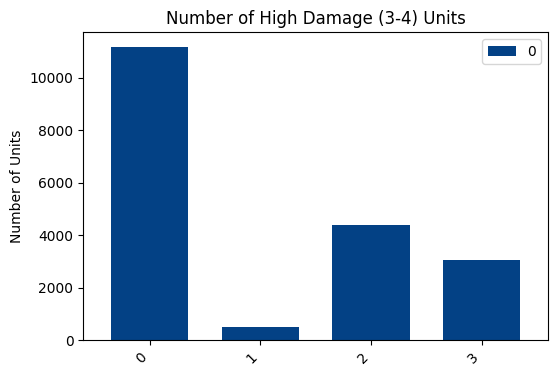

In [78]:

plt.figure(dpi = dpi)
damage_counts = pd.DataFrame(res_dam_units) #, index=inventory_names)
ax = damage_counts.plot(kind='bar', figsize=(6, 4), width=0.7, color = colors)
# ax.set_ylim([30000,42000])
plt.xticks(rotation=45) 
plt.ylabel('Number of Units')
ax.set_title('Number of High Damage (3-4) Units')
plt.xticks(rotation=45, ha='right')
plt.show()

In [79]:
# res_classes = ["RES2", "RES1", "RES3"]
res_classes = ["RES2", "RES1", "RES3A","RES3B","RES3C","RES3D","RES3E","RES3F"]

counts = []

for df, name in zip(inventories, inventory_names):

    # filter to DS >= 3
    df_filt = df[df["DS"] >= 3]

    # count entries containing each RES class
    c = pd.Series(
        {
            res: df_filt["OccupancyClass_Actual"].str.contains(res, na=False).sum()
            for res in res_classes
        },
        name=name
    )

    counts.append(c)

count_df = pd.concat(counts, axis=1)


In [80]:
res_classes = ["RES2", "RES1", "RES3A","RES3B","RES3C","RES3D","RES3E","RES3F"]

counts = []

for df, name in zip(inventories, inventory_names):

    # filter to DS >= 3
    df_filt = df[df["DS"] >= 3]

    # sum NumberOfUnits for each RES class
    c = pd.Series(
        {
            res: df_filt.loc[
                df_filt["OccupancyClass_Actual"].str.contains(res, na=False),
                "NumberOfUnits"
            ].sum()
            for res in res_classes
        },
        name=name
    )

    counts.append(c)

units_df = pd.concat(counts, axis=1)


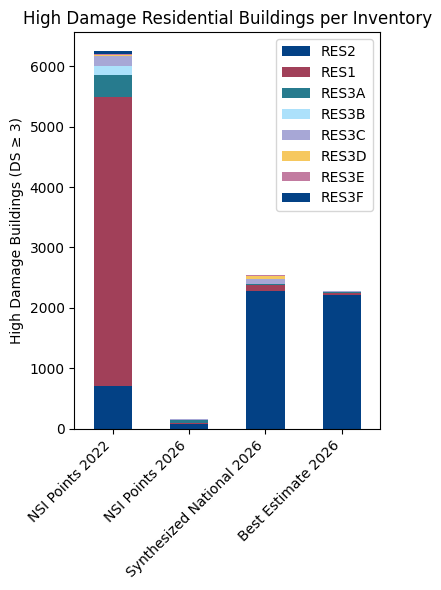

In [81]:

fig, ax = plt.subplots(figsize=(4, 6))
count_df.T.plot(kind="bar",stacked=True,ax=ax, color = colors) #[colors[3],colors[2],colors[0]])

ax.set_ylabel("High Damage Buildings (DS ≥ 3)")
ax.set_xlabel("")
ax.set_title("High Damage Residential Buildings per Inventory")
ax.legend(loc="upper right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


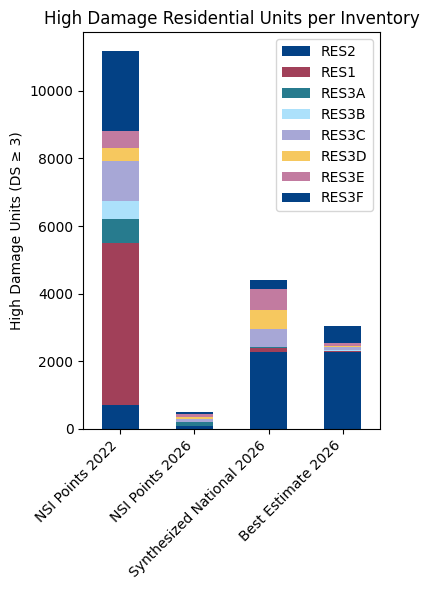

In [82]:

fig, ax = plt.subplots(figsize=(4, 6))
units_df.T.plot(kind="bar",stacked=True,ax=ax, color = colors) #[colors[3],colors[2],colors[0],colors[4]])

ax.set_ylabel("High Damage Units (DS ≥ 3)")
ax.set_xlabel("")
ax.set_title("High Damage Residential Units per Inventory")
ax.legend(loc="upper right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [89]:
res = national26[national26['OccupancyClass_Actual'].str.contains('RES1|RES2|RES3')]
high_dam = res[res['DS']>=3]
print(len(high_dam))
nat_high = high_dam[~high_dam['OccupancyClass_Actual'].str.contains('RES2')]
print(len(nat_high))

res = best26[best26['OccupancyClass_Actual'].str.contains('RES1|RES2|RES3')]
high_dam = res[res['DS']>=3]
print(len(high_dam))
best_high = high_dam[~high_dam['OccupancyClass_Actual'].str.contains('RES2')]
print(len(best_high))

2545
272
2284
71


In [92]:
best_high['BuildingType'].value_counts()

BuildingType
M    62
C     6
S     3
Name: count, dtype: int64

In [93]:
nat_high['BuildingType'].value_counts()

BuildingType
M    168
C     64
S     40
Name: count, dtype: int64

### MOBILE HOMES

In [ ]:

# Set max and min 
vmin  = 0
vmax = 0.7 #max(gdf[value_col].max() for gdf, value_col in zip(gdfs, value_columns))

# Filter data for box bb2
bb2_df = gpd.GeoDataFrame(geometry=[bb2], crs=raw26.crs)
raw22_bb2 = gpd.sjoin(raw22, bb2_df, predicate="intersects")
raw_bb2 = gpd.sjoin(raw26, bb2_df, predicate="intersects")
national_bb2 = gpd.sjoin(national26, bb2_df, predicate="intersects")
best_bb2 = gpd.sjoin(best26, bb2_df, predicate="intersects")


# Define custom colors for known categories
color_dict = {
    'RES1': '#1f77b4',   
    'RES2': "#a14059",  
    'RES3A': "#3cb371",  
    'RES3B': '#308f5a',  
    'RES3C': "#246b44",   
    'RES3D': '#18482d',   
    'RES3E': '#0c2417',  
    'RES3F': 'black',   
    'COM1':'pink',
    'COM3':'darkorange',
    'GOV1':'red'
}

color_dict = {
    'RES1': '#1f77b4',   
    'RES2': "#a14059",  
    'RES3A': "#3cb371",  
    'RES3B': '#3cb371',  
    'RES3C': "#3cb371",   
    'RES3D': '#3cb371',   
    'RES3E': '#3cb371',  
    'RES3F': '#3cb371',   
    'COM1': colors[5],
    'COM3':'darkorange',
}

color_dict = {
    'RES1': 'gray',   
    'RES2': "#a14059",  
    'RES3A': "#5aa0d1",  
    'RES3B': "#5aa0d1", 
    'RES3C': "#5aa0d1", 
    'RES3D': "#5aa0d1", 
    'RES3E': "#5aa0d1", 
    'RES3F': "#5aa0d1", 
    'COM1': colors[5],
    'COM3':'darkorange',
}


# Define a single fallback color for all other (unlisted) categories
fallback_color = '#7f7f7f'  # gray
fallback_color = 'black'  # gray

# Map colors to each GeoDataFrame (use fallback if missing)
for gdf in [raw22_bb2, raw_bb2, national_bb2, best_bb2]:
    gdf['color'] = gdf['OccupancyClass_Actual'].map(color_dict).fillna(fallback_color)





# Plot results 
fig, ax = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True, dpi=dpi)

ms = 4
raw22_bb2.plot(color=raw22_bb2['color'], ax=ax[0], markersize=ms)
raw_bb2.plot(color=raw_bb2['color'], ax=ax[1], markersize=ms)
national_bb2.plot(color=national_bb2['color'], ax=ax[2], markersize=ms)
best_bb2.plot(color=best_bb2['color'], ax=ax[3], markersize=ms)


# Add basemap
for i in range(4):
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels) 

# Plot tile 
ax[0].set_title('NSI22 Point Inventory')
ax[1].set_title('NSI26 Point Inventory')
ax[2].set_title('Synthesized National Inventory')
ax[3].set_title('Best Estimate Inventory')


ax[0].set_xticks([])
ax[0].set_yticks([])


# Legend
# legend_items = color_dict.copy()
# legend_items['Non-Residential'] = fallback_color
# legend = ax[0].legend(
#     handles=[
#         plt.Line2D([0], [0], marker='o', color='w', label=cat,
#                    markerfacecolor=color, markersize=6)
#         for cat, color in legend_items.items()
#     ],
#     title='Occupancy Class',
#     loc='upper left',
#     fontsize=8,
#     title_fontsize=9,
#     frameon=True
# )


# legend_items = {
#     'RES1': '#1f77b4',   
#     'RES2': "#a14059",  
#     'RES3': "#3cb371",    
#     'COM1': colors[5],
#     'COM3':'darkorange',
# }

legend_items = {
    'RES1': 'gray',   
    'RES2': "#a14059",  
    'RES3': "#5aa0d1",    
    'COM1': colors[5],
    'COM3':'darkorange',
}


legend_items['Other'] = fallback_color
legend = ax[0].legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w', label=cat,
                   markerfacecolor=color, markersize=8)
        for cat, color in legend_items.items()
    ],
    title='Occupancy Class',
    loc='upper left',
    fontsize=8,
    title_fontsize=9,
    frameon=True
)


# Make legend background opaque white with optional border
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(1.0) 

plt.tight_layout()

In [ ]:

# Set max and min 
vmin  = 0
vmax = 0.7 #max(gdf[value_col].max() for gdf, value_col in zip(gdfs, value_columns))

fig, ax = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
ms = 4
raw22_bb2.plot(column='DV', cmap=cmap, ax=ax[0], markersize=ms)
raw_bb2.plot(column='DV', cmap=cmap, ax=ax[1], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
national_bb2.plot(column='DV', cmap=cmap, ax=ax[2], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
best_bb2.plot(column='DV', cmap=cmap, ax=ax[3], legend=False, vmin=vmin, vmax=vmax, markersize=ms)



# Add basemap
for i in range(4):

    # Add the OpenStreetMap basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

    # Add boxes to point out features
    for bb in [bb2]:
        gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
        gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)

# Plot tile 
ax[0].set_title('NSI22 Point Inventory')
ax[1].set_title('NSI26 Point Inventory')
ax[2].set_title('Synthesized National Inventory')
ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax[0].set_xticks([])
ax[0].set_yticks([])

# plt.xlim(xbounds)
# plt.ylim(ybounds)
plt.tight_layout()


# Add a single colorbar for all subplots
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  # Necessary for ScalarMappable
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Mean Loss Ratio', fontsize = 12)

### MASONRY

In [ ]:

# Set max and min 
vmin  = 0
vmax = 0.7 #max(gdf[value_col].max() for gdf, value_col in zip(gdfs, value_columns))

# Filter data for box bb2
bb3_df = gpd.GeoDataFrame(geometry=[bb3], crs=raw22.crs)
raw22_bb3 = gpd.sjoin(raw22, bb3_df, predicate="intersects")
raw_bb3 = gpd.sjoin(raw26, bb3_df, predicate="intersects")
national_bb3 = gpd.sjoin(national26, bb3_df, predicate="intersects")
best_bb3 = gpd.sjoin(best26, bb3_df, predicate="intersects")


# Define custom colors for known categories
color_dict = {
    'M': colors[5],   # blue
    'W': "#a14059",   # orange

}

# Define a single fallback color for all other (unlisted) categories
fallback_color = '#7f7f7f'  # gray

# Map colors to each GeoDataFrame (use fallback if missing)
for gdf in [raw22_bb3, raw_bb3, national_bb3, best_bb3]:
    gdf['color'] = gdf['BuildingType'].map(color_dict).fillna(fallback_color)



# Plot results 
fig, ax = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True, dpi=dpi)

ms = 4
raw22_bb3.plot(color=raw22_bb3['color'], ax=ax[0], markersize=ms)
raw_bb3.plot(color=raw_bb3['color'], ax=ax[1], markersize=ms)
national_bb3.plot(color=national_bb3['color'], ax=ax[2], markersize=ms)
best_bb3.plot(color=best_bb3['color'], ax=ax[3], markersize=ms)


# Add basemap
for i in range(4):
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

    # Add boxes to point out features
    for bb in [bb2]:
        gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
        gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)



# Plot tile 
ax[0].set_title('NSI22 Point Inventory')
ax[1].set_title('NSI26 Point Inventory')
ax[2].set_title('Synthesized National Inventory')
ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax[0].set_xticks([])
ax[0].set_yticks([])

# Legend
legend_items = {
    'Masonry': colors[5],   # blue
    'Wood': "#a14059",   # orange
}


legend_items['Other'] = fallback_color
legend = ax[0].legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w', label=cat,
                   markerfacecolor=color, markersize=8)
        for cat, color in legend_items.items()
    ],
    title='Building Type',
    loc='lower left',
    fontsize=8,
    title_fontsize=9,
    frameon=True
)
# Make legend background opaque white with optional border
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(1.0) 

plt.tight_layout()

In [ ]:

# Set max and min 

# Set max and min 
vmin  = 0
vmax = 0.7
cmap = "RdYlBu_r" 

bb3_df = gpd.GeoDataFrame(geometry=[bb3], crs=raw22.crs)
raw22_bb3 = gpd.sjoin(raw22, bb3_df, predicate="intersects")
raw_bb3 = gpd.sjoin(raw26, bb3_df, predicate="intersects")
national_bb3 = gpd.sjoin(national26, bb3_df, predicate="intersects")
best_bb3 = gpd.sjoin(best26, bb3_df, predicate="intersects")


fig, ax = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
ms = 2
raw22_bb3.plot(column='DV', cmap=cmap, ax=ax[0], vmin=vmin, vmax=vmax, markersize=ms)
raw_bb3.plot(column='DV', cmap=cmap, ax=ax[1], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
national_bb3.plot(column='DV', cmap=cmap, ax=ax[2], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
best_bb3.plot(column='DV', cmap=cmap, ax=ax[3], legend=False, vmin=vmin, vmax=vmax, markersize=ms)



# Add basemap
for i in range(4):

    # Add the OpenStreetMap basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

    # Add boxes to point out features
    for bb in [bb2]:
        gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
        gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)

# Plot tile 
ax[0].set_title('NSI22 Point Inventory')
ax[1].set_title('NSI26 Point Inventory')
ax[2].set_title('Synthesized National Inventory')
ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax[0].set_xticks([])
ax[0].set_yticks([])

# plt.xlim(xbounds)
# plt.ylim(ybounds)
plt.tight_layout()


# Add a single colorbar for all subplots
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  # Necessary for ScalarMappable
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Mean Loss Ratio', fontsize = 12)

### YEAR

In [ ]:
def get_year(source1, make_ftpt):

    if make_ftpt: 
        # Bring in footprint geometry and convert to gdf
        merged_footprints = source1[['YearBuilt','FootprintID']].merge(footprints[['FootprintID','geometry']], on='FootprintID')
        merged_footprints = gpd.GeoDataFrame(merged_footprints, geometry='geometry')
        merged_footprints.set_crs(crs_main, inplace=True)
    else: 
        merged_footprints = source1.copy()

    # Label color based on year 
    merged_footprints['color'] = 'gray'  # Default color
    merged_footprints.loc[merged_footprints['YearBuilt'] < 1945, 'color'] = 'red'
    merged_footprints.loc[(merged_footprints['YearBuilt'] >= 1945) & (merged_footprints['YearBuilt'] < 1970), 'color'] = '#f7b52f'
    merged_footprints.loc[(merged_footprints['YearBuilt'] >= 1970) & (merged_footprints['YearBuilt'] < 1980), 'color'] = 'tab:green'
    merged_footprints.loc[(merged_footprints['YearBuilt'] >= 1980) & (merged_footprints['YearBuilt'] < 2000), 'color'] = 'tab:blue'
    merged_footprints.loc[merged_footprints['YearBuilt'] >= 2000, 'color'] = 'purple'

    merged_footprints = merged_footprints.to_crs(crs_plot)

    return merged_footprints

In [ ]:
national26['FootprintID'] = national26['FootprintID'].astype(int)
best26['FootprintID'] = best26['FootprintID'].astype(int)

national26['YearBuilt'] = national26['YearBuilt'].astype(float)
best26['YearBuilt'] = best26['YearBuilt'].astype(float)
raw26['YearBuilt'] = raw26['YearBuilt'].astype(float)
raw22['YearBuilt'] = raw22['YearBuilt'].astype(float)

raw22yr = get_year(raw22, False)
rawyr = get_year(raw26, False)
nationalyr = get_year(national26, False)
bestyr = get_year(best26, False)




ms = 0.3
fig, ax = plt.subplots(1,4, figsize = (15,10), sharex=True, sharey=True, dpi = dpi)
raw22yr.plot(ax=ax[0], color=raw22yr['color'], markersize=ms)
rawyr.plot(ax=ax[1], color=rawyr['color'], markersize=ms)
nationalyr.plot(ax=ax[2], color=nationalyr['color'], markersize=ms)
bestyr.plot(ax=ax[3], color=bestyr['color'], markersize=ms)

# Add bounds
ax[0].set_xlim(xbounds)
ax[0].set_ylim(ybounds)

ax[0].set_title('NSI22 Point Inventory')
ax[1].set_title('NSI26 Point Inventory')
ax[2].set_title('Synthesized National Inventory')
ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax[0].set_xticks([])
ax[0].set_yticks([])

for i in range(3):
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels, zoom = 12)
    # Add clear box to remove distortion in plot 
    bb = box(-122.091127,37.636333,-122.080399,37.643282)
    gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
    gdf_bb.boundary.plot(ax=ax[i], alpha = 0, color = 'black')

# Add a legend
legend_patches = [
    mpatches.Patch(color='red', label='Before 1945'),
    mpatches.Patch(color='#f7b52f', label='1945-1970'),
    mpatches.Patch(color='tab:green', label='1970-1980'),
    mpatches.Patch(color='tab:blue', label='1980-2000'),
    mpatches.Patch(color='purple', label='2000 and later')
]
ax[0].legend(handles=legend_patches, loc='upper left', fontsize = 9)

plt.tight_layout()
# plt.savefig(fig_dir + "year_built.svg", format="svg",  bbox_inches='tight', pad_inches=0)
# plt.savefig(fig_dir + "year_built.png",  bbox_inches='tight', pad_inches=0)
# # plt.close()


In [ ]:


# Filter data for box bb2
bb3_df = gpd.GeoDataFrame(geometry=[bb1], crs=raw22.crs)
raw22_bb3 = gpd.sjoin(raw22, bb3_df, predicate="intersects")
raw_bb3 = gpd.sjoin(raw26, bb3_df, predicate="intersects")
national_bb3 = gpd.sjoin(national26, bb3_df, predicate="intersects")
best_bb3 = gpd.sjoin(best26, bb3_df, predicate="intersects")



# Set max and min 
vmin  = 0
vmax = 0.7 #max(gdf[value_col].max() for gdf, value_col in zip(gdfs, value_columns))

fig, ax = plt.subplots(1, 4, figsize=(13, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
ms = 10
raw22_bb3.plot(column='DV', cmap=cmap, ax=ax[0], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
raw_bb3.plot(column='DV', cmap=cmap, ax=ax[1], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
national_bb3.plot(column='DV', cmap=cmap, ax=ax[2], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
best_bb3.plot(column='DV', cmap=cmap, ax=ax[3], legend=False, vmin=vmin, vmax=vmax, markersize=ms)



# Add basemap
for i in range(4):

    # Add the OpenStreetMap basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

    # Add boxes to point out features
    for bb in [bb2]:
        gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
        gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)


# Plot tile 
ax[0].set_title('NSI22 Point Inventory')
ax[1].set_title('NSI26 Point Inventory')
ax[2].set_title('Synthesized National Inventory')
ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax[0].set_xticks([])
ax[0].set_yticks([])


# plt.xlim(xbounds)
# plt.ylim(ybounds)
plt.tight_layout()


# Add a single colorbar for all subplots
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  # Necessary for ScalarMappable
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Mean Loss Ratio', fontsize = 12)

In [ ]:

# Filter data for box bb2
bb3_df = gpd.GeoDataFrame(geometry=[bb1], crs=raw22.crs)
raw22_bb3 = gpd.sjoin(raw22yr, bb3_df, predicate="intersects")
raw_bb3 = gpd.sjoin(rawyr, bb3_df, predicate="intersects")
national_bb3 = gpd.sjoin(nationalyr, bb3_df, predicate="intersects")
best_bb3 = gpd.sjoin(bestyr, bb3_df, predicate="intersects")




fig, ax = plt.subplots(1, 4, figsize=(13, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
ms = 10
raw22_bb3.plot(ax=ax[0], color=raw22_bb3['color'], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
raw_bb3.plot(color=raw_bb3['color'], ax=ax[1], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
national_bb3.plot(color=national_bb3['color'], ax=ax[2], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
best_bb3.plot(color=best_bb3['color'],ax=ax[3], legend=False, vmin=vmin, vmax=vmax, markersize=ms)



# Add basemap
for i in range(4):

    # Add the OpenStreetMap basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

    # Add boxes to point out features
    for bb in [bb2]:
        gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
        gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)


# Plot tile 
ax[0].set_title('NSI22 Point Inventory')
ax[1].set_title('NSI26 Point Inventory')
ax[2].set_title('Synthesized National Inventory')
ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax[0].set_xticks([])
ax[0].set_yticks([])


# plt.xlim(xbounds)
# plt.ylim(ybounds)
plt.tight_layout()


# # Add a single colorbar for all subplots
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
# sm._A = []  # Necessary for ScalarMappable
# cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
# cbar.set_label('Mean Loss Ratio', fontsize = 12)

In [ ]:
raw22_bb3.columns

In [ ]:

# Filter data for box bb2
bb3_df = gpd.GeoDataFrame(geometry=[bb1], crs=raw22.crs)
raw22_bb3 = gpd.sjoin(raw22yr, bb3_df, predicate="intersects")
raw_bb3 = gpd.sjoin(rawyr, bb3_df, predicate="intersects")
national_bb3 = gpd.sjoin(nationalyr, bb3_df, predicate="intersects")
best_bb3 = gpd.sjoin(bestyr, bb3_df, predicate="intersects")




# Set max and min 
vmin  = 1945
vmax = 2000
cmap = 'turbo'


fig, ax = plt.subplots(1, 4, figsize=(13, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
ms = 10
raw22_bb3.plot(column = 'YearBuilt', cmap = cmap, ax=ax[0],legend=False, vmin=vmin, vmax=vmax, markersize=ms)
raw_bb3.plot(column = 'YearBuilt', cmap = cmap, ax=ax[1],legend=False, vmin=vmin, vmax=vmax, markersize=ms)
national_bb3.plot(column = 'YearBuilt', cmap = cmap, ax=ax[2],legend=False, vmin=vmin, vmax=vmax, markersize=ms)
best_bb3.plot(column = 'YearBuilt', cmap = cmap, ax=ax[3],legend=False, vmin=vmin, vmax=vmax, markersize=ms)

# Add basemap
for i in range(4):

    # Add the OpenStreetMap basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

    # Add boxes to point out features
    for bb in [bb2]:
        gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
        gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)


# Plot tile 
ax[0].set_title('NSI22 Point Inventory')
ax[1].set_title('NSI26 Point Inventory')
ax[2].set_title('Synthesized National Inventory')
ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax[0].set_xticks([])
ax[0].set_yticks([])


# plt.xlim(xbounds)
# plt.ylim(ybounds)
plt.tight_layout()


# Add a single colorbar for all subplots
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  # Necessary for ScalarMappable
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Mean Loss Ratio', fontsize = 12)

In [ ]:

# Filter data for box bb2
bb3_df = gpd.GeoDataFrame(geometry=[bb1], crs=raw22.crs)
raw22_bb3 = gpd.sjoin(raw22yr, bb3_df, predicate="intersects")
raw_bb3 = gpd.sjoin(rawyr, bb3_df, predicate="intersects")
national_bb3 = gpd.sjoin(nationalyr, bb3_df, predicate="intersects")
best_bb3 = gpd.sjoin(bestyr, bb3_df, predicate="intersects")




# Set max and min 
vmin  = 1945
vmax = 2000
cmap = 'PiYG'


fig, ax = plt.subplots(1, 4, figsize=(13, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
ms = 10
raw22_bb3.plot(column = 'DesignLevel', cmap = cmap, ax=ax[0],legend=False, markersize=ms)
raw_bb3.plot(column = 'DesignLevel', cmap = cmap, ax=ax[1],legend=False, markersize=ms)
national_bb3.plot(column = 'DesignLevel', cmap = cmap, ax=ax[2],legend=False, markersize=ms)
best_bb3.plot(column = 'DesignLevel', cmap = cmap, ax=ax[3],legend=False, markersize=ms)

# Add basemap
for i in range(4):

    # Add the OpenStreetMap basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

    # Add boxes to point out features
    for bb in [bb2]:
        gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
        gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)


# Plot tile 
ax[0].set_title('NSI22 Point Inventory')
ax[1].set_title('NSI26 Point Inventory')
ax[2].set_title('Synthesized National Inventory')
ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax[0].set_xticks([])
ax[0].set_yticks([])


# plt.xlim(xbounds)
# plt.ylim(ybounds)
plt.tight_layout()



In [ ]:
## LINK FOOTPRINTS 
print(len(national26))
print(len(best26))
nat_best = national26.merge(best26, on = 'FootprintID', how = 'inner')
print(len(nat_best))

fig, ax = plt.subplots(1,2, figsize = (12,6))

ax[0].scatter(nat_best['YearBuilt_x'],nat_best['YearBuilt_y'], alpha = 0.03, s = 8)
ax[0].set_xlabel('NSI26 Year of Construction')
ax[0].set_ylabel('Best Estimate Year of Construction')
ax[0].set_xlim([1890,2030])
ax[0].set_ylim([1890,2030])
ax[0].set_title('Year Built Scatter Plot \n (Only Footprints with Both Data Sources)')



nat_best['diff'] = nat_best['YearBuilt_x'] - nat_best['YearBuilt_y']
nat_best['abs_diff'] = np.abs(nat_best['YearBuilt_x'] - nat_best['YearBuilt_y'])
print(nat_best['abs_diff'].mean())

ax[1].hist(nat_best['diff'], bins = 30, edgecolor = 'black')
ax[1].set_xlabel('Difference in NSI26 Year and Best Estimate Year')
ax[1].set_ylabel('Number of Building Footprints')
ax[1].set_title('Difference between Synthesized National Year Built \nand Best Estimate Year Built')

plt.tight_layout()
plt.show()

In [ ]:
## NOTE - REMAKE ABOVE PLOT WITH ONly ENTRIES THAT ARE DIFFERENT 

all_fields = fxns.json_to_gdf('./Inventory_Outputs/Best_Estimate/InventoryGeneration/Inventory_AllFields.json', crs_main)

fig, ax = plt.subplots(2,2, figsize = (12,12))
ax[0,0].scatter(all_fields['NSI_MedYearBuilt_Single'],all_fields['Parcel_EffYearBuilt_Single'], alpha = 0.03, s = 8)
ax[0,0].set_xlim([1890,2030])
ax[0,0].set_ylim([1890,2030])

ax[0,1].scatter(all_fields['NSI_MedYearBuilt_Single'],all_fields['Parcel_YearBuilt_Single'], alpha = 0.03, s = 8)
ax[0,1].set_xlim([1890,2030])
ax[0,1].set_ylim([1890,2030])




all_fields['diff_with_eff'] = all_fields['NSI_MedYearBuilt_Single'] - all_fields['Parcel_EffYearBuilt_Single']
all_fields['diff_with_yr'] = all_fields['NSI_MedYearBuilt_Single'] - all_fields['Parcel_YearBuilt_Single']

ax[1,0].hist(all_fields['diff_with_eff'], bins = 30, edgecolor = 'black')
ax[1,1].hist(all_fields['diff_with_yr'], bins = 30, edgecolor = 'black')
# ax[1].set_xlabel('Difference in NSI26 Year and Best Estimate Year')
# ax[1].set_ylabel('Number of Building Footprints')
# ax[1].set_title('Difference between Synthesized National Year Built \nand Best Estimate Year Built')

# plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots()
x = np.sort(all_fields['diff_with_eff'].dropna())
y = np.arange(1, len(x)+1) / len(x)
ax.plot(x, y)
ax.set_ylabel("Cumulative Probability")
ax.set_xlabel("diff_with_eff")


In [ ]:
### PLOT BY CENSUS TRACT

fig, ax = plt.subplots()

all_fields = fxns.json_to_gdf('./Inventory_Outputs/Best_Estimate/InventoryGeneration/Inventory_AllFields.json', crs_main)
all_fields['diff_with_eff'] = all_fields['NSI_MedYearBuilt_Single'] - all_fields['Parcel_EffYearBuilt_Single']
all_fields['diff_with_yr'] = all_fields['NSI_MedYearBuilt_Single'] - all_fields['Parcel_YearBuilt_Single']

tracts = list(all_fields['CensusTract'].unique())
means = []
abs_means = []
stds = []
abs_stds = []
proportion_res = []
proportion_res1 = []


for i, tract in enumerate(tracts): 
    tract_data = all_fields[all_fields['CensusTract']==tract]

    if len(tract_data) > 100: 

        ## COMPUTE STANDARD DEVIATION 
        stds.append(np.std(tract_data['diff_with_eff']))
        abs_stds.append(np.std(np.abs(tract_data['diff_with_eff'])))
        means.append(np.mean(tract_data['diff_with_eff']))
        abs_means.append(np.mean(np.abs(tract_data['diff_with_eff'])))

        ## COMPUTE PROPORTION OF RES
        proportion_res.append(len(tract_data[tract_data['OccupancyClass_Best'].str.contains('RES')])/len(tract_data))

        ## COMPUTE PROPORITON OF RES1 
        proportion_res1.append(len(tract_data[tract_data['OccupancyClass_Best'].str.contains('RES1')])/len(tract_data))

        if i == 0: 
            x = np.sort(tract_data['diff_with_eff'].dropna())
            y = np.arange(1, len(x)+1) / len(x)
            ax.plot(x, y, alpha = 0.2, color = colors[0], label = 'CDF by Tract')
        else:
            x = np.sort(tract_data['diff_with_eff'].dropna())
            y = np.arange(1, len(x)+1) / len(x)
            ax.plot(x, y, alpha = 0.2, color = colors[0])
    
    else: 
        print('tract less than 100')

std_total = (np.std(all_fields['diff_with_eff']))
mean_total = (np.mean(all_fields['diff_with_eff']))
abs_mean_total = (np.mean(np.abs(all_fields['diff_with_eff'])))

x = np.sort(all_fields['diff_with_eff'].dropna())
y = np.arange(1, len(x)+1) / len(x)
ax.plot(x, y, alpha = 1, color = colors[1], linewidth = 3, label = 'CDF for all Data')
ax.legend()
ax.set_xlabel('Difference in NSI26 Year and Best Estimate Year')
ax.set_ylabel('Empirical CDF')
ax.set_title('Empirical CDF of Difference between NSI Year and Best Estimate Year')


In [ ]:
## PLOT MEAN 
plt.hist(means, bins=30, edgecolor='black')
plt.xlabel('Standard Deviation of Difference between NSI Year and Best Year, by Census Tract')
plt.ylabel('Number of Census Tracts')
plt.title('Mean Difference in Year per Tract')
plt.show()

plt.hist(abs_means, bins=30, edgecolor='black')
plt.xlabel('Standard Deviation of Difference between NSI Year and Best Year, by Census Tract')
plt.ylabel('Number of Census Tracts')
plt.title('Abs Mean Difference in Year per Tract')
plt.show()

## PLOT STANDARD DEVIATION 
plt.hist(stds, bins=30, edgecolor='black')
plt.axvline(x=std_total, color = 'gray')
plt.xlabel('Standard Deviation of Difference between NSI Year and Best Year, by Census Tract')
plt.ylabel('Number of Census Tracts')
plt.title('Std in Year per Tract')
plt.show()


## PLOT STANDARD DEVIATION 
plt.hist(abs_stds, bins=30, edgecolor='black')
plt.xlabel('Standard Deviation of Abs Difference between NSI Year and Best Year, by Census Tract')
plt.ylabel('Number of Census Tracts')
plt.title('Std in Year per Tract')
plt.show()

In [ ]:
plt.axvline(x=abs_mean_total)
sc = plt.scatter(np.sort(abs_means), range(len(abs_means)),c=proportion_res, vmin = 0.8, vmax = 1, cmap='Reds')
plt.xlabel('Standard Deviation of Difference between NSI Year and Best Year\n by Census Tract')
plt.colorbar(sc, label='Proportion of Tract that is Residential')
plt.ylabel('Order')
plt.title("Mean Abs Diff, Colored by Proportion RES")
plt.show()

plt.axvline(x=abs_mean_total)
sc = plt.scatter(np.sort(abs_means), range(len(abs_means)),c=proportion_res1, vmin = 0.5, vmax = 1, cmap='Reds')
plt.xlabel('Standard Deviation of Difference between NSI Year and Best Year\n by Census Tract')
plt.colorbar(sc, label='Proportion of Tract that is RES1')
plt.ylabel('Order')
plt.title("Mean Abs Diff, Colored by Proportion RES1")
plt.show()




plt.axvline(x=mean_total)
sc = plt.scatter(np.sort(means), range(len(means)),c=proportion_res, vmin = 0.5, vmax = 1, cmap='Reds')
plt.xlabel('Standard Deviation of Difference between NSI Year and Best Year\n by Census Tract')
plt.colorbar(sc, label='Proportion of Tract that is Residential')
plt.ylabel('Order')
plt.title("Mean Diff, Colored by Proportion RES")
plt.show()

plt.axvline(x=mean_total)
sc = plt.scatter(np.sort(means), range(len(means)),c=proportion_res1, vmin = 0.5, vmax = 1, cmap='Reds')
plt.xlabel('Standard Deviation of Difference between NSI Year and Best Year\n by Census Tract')
plt.colorbar(sc, label='Proportion of Tract that is Residential')
plt.ylabel('Order')
plt.title("Mean Diff, Colored by Proportion RES1")
plt.show()

In [ ]:

plt.axvline(x=std_total)
sc = plt.scatter(np.sort(abs_stds), range(len(abs_stds)),c=proportion_res, cmap='Reds')
plt.xlabel('Standard Deviation of Difference between NSI Year and Best Year\n by Census Tract')
plt.colorbar(sc, label='Proportion of Tract that is Residential')
plt.ylabel('Order')
plt.title("Standard Dev of Abs Diff, Colored by Proportion RES")
plt.show()

plt.axvline(x=std_total)
sc = plt.scatter(np.sort(abs_stds), range(len(abs_stds)),c=proportion_res1, cmap='Reds')
plt.xlabel('Standard Deviation of Difference between NSI Year and Best Year\n by Census Tract')
plt.colorbar(sc, label='Proportion of Tract that is Residential')
plt.ylabel('Order')
plt.title("Standard Dev of Abs Diff, Colored by Proportion RES1")
plt.show()



plt.axvline(x=std_total)
sc = plt.scatter(np.sort(stds), range(len(stds)),c=proportion_res, cmap='Reds')
plt.xlabel('Standard Deviation of Difference between NSI Year and Best Year\n by Census Tract')
plt.colorbar(sc, label='Proportion of Tract that is Residential')
plt.ylabel('Order')
plt.title("Standard Dev, Colored by Proportion RES")
plt.show()

plt.axvline(x=std_total)
sc = plt.scatter(np.sort(stds), range(len(stds)),c=proportion_res1, cmap='Reds')
plt.xlabel('Standard Deviation of Difference between NSI Year and Best Year\n by Census Tract')
plt.colorbar(sc, label='Proportion of Tract that is Residential')
plt.ylabel('Order')
plt.title("Standard Dev, Colored by Proportion RES1")
plt.show()


In [ ]:
### PLOT BY CENSUS TRACT, RES DATA ONLY 

fig, ax = plt.subplots()

all_fields = fxns.json_to_gdf('./Inventory_Outputs/Best_Estimate/InventoryGeneration/Inventory_AllFields.json', crs_main)
all_fields['diff_with_eff'] = all_fields['NSI_MedYearBuilt_Single'] - all_fields['Parcel_EffYearBuilt_Single']
all_fields['diff_with_yr'] = all_fields['NSI_MedYearBuilt_Single'] - all_fields['Parcel_YearBuilt_Single']

tracts = list(all_fields['CensusTract'].unique())


for i, tract in enumerate(tracts): 
    tract_data = all_fields[all_fields['CensusTract']==tract]
    tract_data = tract_data[tract_data['OccupancyClass_Best'].str.contains('RES')]

    if len(tract_data) > 100: 

        if i == 0: 
            x = np.sort(tract_data['diff_with_eff'].dropna())
            y = np.arange(1, len(x)+1) / len(x)
            ax.plot(x, y, alpha = 0.2, color = colors[0], label = 'CDF by Tract')
        else:
            x = np.sort(tract_data['diff_with_eff'].dropna())
            y = np.arange(1, len(x)+1) / len(x)
            ax.plot(x, y, alpha = 0.2, color = colors[0])
    else: 
        print('less than 100')

res = all_fields[all_fields['OccupancyClass_Best'].str.contains('RES')]
x = np.sort(res['diff_with_eff'].dropna())
y = np.arange(1, len(x)+1) / len(x)
ax.plot(x, y, alpha = 1, color = colors[1], linewidth = 3, label = 'CDF for all Data')
ax.legend()
ax.set_xlabel('Difference in NSI26 Year and Best Estimate Year')
ax.set_ylabel('Empirical CDF')
ax.set_title('CDF for Residential Data Only')

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (12,6))

ax[0].scatter(all_fields['NSI_MedYearBuilt_Single'],all_fields['Parcel_EffYearBuilt_Single'], alpha = 0.03, s = 8)
ax[0].plot([1890, 2030], [1890, 2030], color='black', linestyle='--', linewidth=1)
ax[0].set_xlabel('NSI26 Year of Construction')
ax[0].set_ylabel('Best Estimate Year of Construction')
ax[0].set_xlim([1890,2030])
ax[0].set_ylim([1890,2030])
ax[0].set_title('Year Built Scatter Plot \n (Only Footprints with Both Data Sources)')


diff_mean = all_fields['diff_with_eff'].mean()
abs_diff_mean = abs(all_fields['diff_with_eff']).mean()
print(all_fields['diff_with_eff'].mean())
print(abs(all_fields['diff_with_eff']).mean())
all_fields['diff_with_eff'] = all_fields['NSI_MedYearBuilt_Single'] - all_fields['Parcel_EffYearBuilt_Single']
all_fields['diff_with_yr'] = all_fields['NSI_MedYearBuilt_Single'] - all_fields['Parcel_YearBuilt_Single']

ax[1].hist(all_fields['diff_with_eff'], bins = 40, edgecolor = 'black')
# ax[1].axvline(x=0, color='lightgray', linestyle='--', linewidth=1)
ax[1].set_xlabel('Difference in NSI26 Year and Best Estimate Year')
ax[1].set_ylabel('Number of Building Footprints')
ax[1].set_title('Difference between Synthesized National Year Built \nand Best Estimate Year Built')


ax[1].text(x = 60, y = 5700, s = f'Mean Difference:{round(diff_mean)}\nMean Absolute Difference:{round(abs_diff_mean)}') #\nMean AbsoluteDifference:{round(abs(all_fields['diff_with_eff']).mean())}')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

dfs = {
    "NSI22 Point": raw22,
    "NSI26 Point": raw26,
    "Synthesized National": national26,
    "Best Estimate": best26
}

prop_list = []

for name, df in dfs.items():
    props = (
        df["DesignLevel"]
        .value_counts()   # proportions
        .rename(name)
    )
    prop_list.append(props)

# Combine into single DataFrame
prop_df = pd.concat(prop_list, axis=1).fillna(0)

ax = prop_df.T.plot(kind="bar",stacked=True,figsize=(8,6))
ax.set_ylabel("Building Count")
ax.set_xlabel("Dataset")
ax.legend(title="DesignLevel", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()



### YEAR/MATERIAL

In [ ]:
print(nat_best['diff'].mean())
print(nat_best['diff'].std())

In [ ]:


# Filter data for box bb2
bb3_df = gpd.GeoDataFrame(geometry=[bb4], crs=raw22.crs)
raw22_bb3 = gpd.sjoin(raw22, bb3_df, predicate="intersects")
raw_bb3 = gpd.sjoin(raw26, bb3_df, predicate="intersects")
national_bb3 = gpd.sjoin(national26, bb3_df, predicate="intersects")
best_bb3 = gpd.sjoin(best26, bb3_df, predicate="intersects")



# Set max and min 
vmin  = 0
vmax = 0.7 #max(gdf[value_col].max() for gdf, value_col in zip(gdfs, value_columns))
cmap = "RdYlBu_r" 

fig, ax = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
ms = 10
raw22_bb3.plot(column='DV', cmap=cmap, ax=ax[0], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
raw_bb3.plot(column='DV', cmap=cmap, ax=ax[1], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
national_bb3.plot(column='DV', cmap=cmap, ax=ax[2], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
best_bb3.plot(column='DV', cmap=cmap, ax=ax[3], legend=False, vmin=vmin, vmax=vmax, markersize=ms)



# Add basemap
for i in range(4):

    # Add the OpenStreetMap basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

    # Add boxes to point out features
    for bb in [bb2]:
        gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
        gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)


# Plot tile 
ax[0].set_title('NSI22 Point Inventory')
ax[1].set_title('NSI26 Point Inventory')
ax[2].set_title('Synthesized National Inventory')
ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax[0].set_xticks([])
ax[0].set_yticks([])


# plt.xlim(xbounds)
# plt.ylim(ybounds)
plt.tight_layout()


# Add a single colorbar for all subplots
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  # Necessary for ScalarMappable
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Mean Loss Ratio', fontsize = 12)

In [ ]:

# Filter data for box bb2
bb3_df = gpd.GeoDataFrame(geometry=[bb4], crs=raw22.crs)
raw22_bb3 = gpd.sjoin(raw22yr, bb3_df, predicate="intersects")
raw_bb3 = gpd.sjoin(rawyr, bb3_df, predicate="intersects")
national_bb3 = gpd.sjoin(nationalyr, bb3_df, predicate="intersects")
best_bb3 = gpd.sjoin(bestyr, bb3_df, predicate="intersects")



# Set max and min 
vmin  = 0
vmax = 0.7 #max(gdf[value_col].max() for gdf, value_col in zip(gdfs, value_columns))

fig, ax = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
ms = 10
raw22_bb3.plot(ax=ax[0], color=raw22_bb3['color'], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
raw_bb3.plot(color=raw_bb3['color'], ax=ax[1], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
national_bb3.plot(color=national_bb3['color'], ax=ax[2], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
best_bb3.plot(color=best_bb3['color'],ax=ax[3], legend=False, vmin=vmin, vmax=vmax, markersize=ms)



# Add basemap
for i in range(4):

    # Add the OpenStreetMap basemap
    ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

    # Add boxes to point out features
    for bb in [bb2]:
        gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
        gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)


# Plot tile 
ax[0].set_title('NSI22 Point Inventory')
ax[1].set_title('NSI26 Point Inventory')
ax[2].set_title('Synthesized National Inventory')
ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax[0].set_xticks([])
ax[0].set_yticks([])


# plt.xlim(xbounds)
# plt.ylim(ybounds)
plt.tight_layout()


# # Add a single colorbar for all subplots
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
# sm._A = []  # Necessary for ScalarMappable
# cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
# cbar.set_label('Mean Loss Ratio', fontsize = 12)

In [ ]:

# # Set max and min 
# vmin  = 0
# vmax = 0.7 #max(gdf[value_col].max() for gdf, value_col in zip(gdfs, value_columns))

# # Filter data for box bb2
# bb3_df = gpd.GeoDataFrame(geometry=[bb4], crs=raw22.crs)
# raw22_bb3 = gpd.sjoin(raw22, bb3_df, predicate="intersects")
# raw_bb3 = gpd.sjoin(raw26, bb3_df, predicate="intersects")
# national_bb3 = gpd.sjoin(national26, bb3_df, predicate="intersects")
# best_bb3 = gpd.sjoin(best26, bb3_df, predicate="intersects")


# # Define custom colors for known categories
# color_dict = {
#     'M': colors[5],   # blue
#     'W': colors[3], 
#     'C': colors[2], 
#     'S': colors[1], 
#     'MH': colors[4], 

# }

# # Define a single fallback color for all other (unlisted) categories
# fallback_color = '#7f7f7f'  # gray

# # Map colors to each GeoDataFrame (use fallback if missing)
# for gdf in [raw22_bb3, raw_bb3, national_bb3, best_bb3]:
#     gdf['color'] = gdf['BuildingType'].map(color_dict).fillna(fallback_color)



# # Plot results 
# fig, ax = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True, dpi=dpi)

# ms = 4
# raw22_bb3.plot(color=raw22_bb3['color'], ax=ax[0], markersize=ms)
# raw_bb3.plot(color=raw_bb3['color'], ax=ax[1], markersize=ms)
# national_bb3.plot(color=national_bb3['color'], ax=ax[2], markersize=ms)
# best_bb3.plot(color=best_bb3['color'], ax=ax[3], markersize=ms)


# # Add basemap
# for i in range(4):
#     ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

#     # Add boxes to point out features
#     for bb in [bb2]:
#         gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
#         gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)



# # Plot tile 
# ax[0].set_title('NSI22 Point Inventory')
# ax[1].set_title('NSI26 Point Inventory')
# ax[2].set_title('Synthesized National Inventory')
# ax[3].set_title('Best Estimate Inventory')

# # Set tick marks for x axis 
# ax[0].set_xticks([])
# ax[0].set_yticks([])

# # Legend
# legend_items =color_dict

# legend_items['Other'] = fallback_color
# legend = ax[0].legend(
#     handles=[
#         plt.Line2D([0], [0], marker='o', color='w', label=cat,
#                    markerfacecolor=color, markersize=10)
#         for cat, color in legend_items.items()
#     ],
#     title='Building Type',
#     loc='lower left',
#     fontsize=8,
#     title_fontsize=9,
#     frameon=True
# )
# # Make legend background opaque white with optional border
# legend.get_frame().set_facecolor('white')
# legend.get_frame().set_edgecolor('black')
# legend.get_frame().set_alpha(1.0) 

# plt.tight_layout()

In [ ]:

# vmin  = 0
# vmax = 0.7
# cmap = "RdYlBu_r" 

# ms = 15
# alpha = 0.4
# fig, ax = plt.subplots(1,4, figsize = (16,5), sharey = True, sharex = True)
# ax[0].scatter(raw22_bb3['BuildingType'],raw22_bb3['YearBuilt'], c=raw22_bb3['DV'], cmap=cmap, vmin = vmin, vmax = vmax, alpha = alpha, s = ms)
# ax[1].scatter(raw_bb3['BuildingType'],raw_bb3['YearBuilt'], c=raw_bb3['DV'], cmap=cmap, vmin = vmin, vmax = vmax, alpha = alpha, s = ms)
# ax[2].scatter(national_bb3['BuildingType'],national_bb3['YearBuilt'], c=national_bb3['DV'], vmin = vmin, vmax = vmax, cmap=cmap, alpha = alpha, s = ms)
# ax[3].scatter(best_bb3['BuildingType'],best_bb3['YearBuilt'],c=best_bb3['DV'], cmap=cmap, vmin = vmin, vmax = vmax, alpha = alpha, s = ms)

# ax[0].set_ylim([1875,2029])
# plt.tight_layout()


# # Plot tile 
# ax[0].set_title('NSI22 Point Inventory')
# ax[1].set_title('NSI26 Point Inventory')
# ax[2].set_title('Synthesized National Inventory')
# ax[3].set_title('Best Estimate Inventory')

# ax[0].set_ylabel('Year Built')
# ax[0].set_xlabel('Building Material')
# ax[1].set_xlabel('Building Material')
# ax[2].set_xlabel('Building Material')
# ax[3].set_xlabel('Building Material')

# # Add a single colorbar for all subplots
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
# sm._A = []  # Necessary for ScalarMappable
# cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
# cbar.set_label('Mean Loss Ratio', fontsize = 12)

In [ ]:
ms = 15
alpha = 0.4

fig, ax = plt.subplots(1, 4, figsize=(14, 5), sharey=True, sharex=True)

dfs = [raw22_bb3, raw_bb3, national_bb3, best_bb3]

for i, df in enumerate(dfs):

    sc = ax[i].scatter(df['BuildingType'],df['YearBuilt'], c=df['DV'], cmap=cmap, vmin = vmin, vmax = vmax, alpha = alpha, s = ms)

    # Add bldg type counts
    counts = df['BuildingType'].value_counts()
    ax[i].set_ylim([1875, 2029])
    
    for x_val, count in counts.items():
        ax[i].text(x_val,1880, f'n={count}', rotation=45, ha='center',va='bottom',fontsize=9)

for a in ax:
    a.set_xlim(-1, 5)


plt.tight_layout()


In [ ]:
# def extract_bldg_type(value):
#     if value in ['RM1','RM2','URM']: 
#         return 'M'
#     elif value in ['W1','W2']: 
#         return 'W'
#     elif value in ['S1','S2','S3','S4','S5']:
#         return 'S'
#     elif value in  ['C1','C2','C3','PC1','PC2']:
#         return 'C'
#     elif value in ['MH']:
#         return 'H'
#     else: 
#         return 'ERROR'
    
# raw22['BldgType_fromStructure'] = raw22['StructureType'].apply(extract_bldg_type)
# raw26['BldgType_fromStructure'] = raw26['StructureType'].apply(extract_bldg_type)
# national26['BldgType_fromStructure'] = national26['StructureType'].apply(extract_bldg_type)
# best26['BldgType_fromStructure'] = best26['StructureType'].apply(extract_bldg_type)

### TEMP

In [ ]:
# national26['FootprintID'] = national26['FootprintID'].astype(int)
# best26['FootprintID'] = best26['FootprintID'].astype(int)

# national26['YearBuilt'] = national26['YearBuilt'].astype(float)
# best26['YearBuilt'] = best26['YearBuilt'].astype(float)
# raw26['YearBuilt'] = raw26['YearBuilt'].astype(float)
# raw22['YearBuilt'] = raw22['YearBuilt'].astype(float)

# raw22yr = get_year(raw22, False)
# rawyr = get_year(raw26, False)
# nationalyr = get_year(national26, False)
bestyr = get_year(best26, True)


In [ ]:
bestyr.plot()

In [ ]:
bb_plot = box(-122.078942,37.617485,-122.067047,37.625297)
bb_plot = box(-122.079341,37.618264,-122.070194,37.625083)
# bb_plot = box(-122.0680540033,37.6595755204,-122.0623957447,37.6627763508)
bb_plot_df = gpd.GeoDataFrame(geometry=[bb_plot], crs=raw26.crs)

# # Filter data for box bb2
# bb3_df = gpd.GeoDataFrame(geometry=[bb4], crs=raw22.crs)
# raw22_bb3 = gpd.sjoin(raw22, bb3_df, predicate="intersects")
# raw_bb3 = gpd.sjoin(raw26, bb3_df, predicate="intersects")
# national_bb3 = gpd.sjoin(national26, bb3_df, predicate="intersects")
best_bb3 = gpd.sjoin(best26, bb_plot_df, predicate="intersects")
# best_ftpt_bb3 = gpd.sjoin(bestyr, bb_plot_df, predicate="intersects")



# Set max and min 
vmin  = 0
vmax = 0.7 #max(gdf[value_col].max() for gdf, value_col in zip(gdfs, value_columns))

fig, ax = plt.subplots(1, 1, figsize=(18, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
ms = 4
# raw22_bb3.plot(column='DV', cmap=cmap, ax=ax[0], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
# raw_bb3.plot(column='DV', cmap=cmap, ax=ax[1], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
# national_bb3.plot(column='DV', cmap=cmap, ax=ax[2], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
best_bb3.plot(column='DV', color = colors[1], ax=ax, legend=False, vmin=vmin, vmax=vmax, markersize=ms, alpha = 0 )

ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik, zoom = 18)

# # Add basemap
# for i in range(4):

#     # Add the OpenStreetMap basemap
#     ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

#     # Add boxes to point out features
#     for bb in [bb2]:
#         gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
#         gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)


# # Plot tile 
# ax[0].set_title('NSI22 Point Inventory')
# ax[1].set_title('NSI26 Point Inventory')
# ax[2].set_title('Synthesized National Inventory')
# ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax.set_xticks([])
ax.set_yticks([])


# plt.xlim(xbounds)
# plt.ylim(ybounds)
plt.tight_layout()


# Add a single colorbar for all subplots
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
# sm._A = []  # Necessary for ScalarMappable
# cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
# cbar.set_label('Mean Loss Ratio', fontsize = 12)
plt.show()

In [ ]:
best_bb3[best_bb3['OccupancyClass']=='RES2']

In [ ]:
bb_plot = box(-122.078942,37.617485,-122.067047,37.625297)
bb_plot_df = gpd.GeoDataFrame(geometry=[bb_plot], crs=raw26.crs)

# # Filter data for box bb2
# bb3_df = gpd.GeoDataFrame(geometry=[bb4], crs=raw22.crs)
# raw22_bb3 = gpd.sjoin(raw22, bb3_df, predicate="intersects")
# raw_bb3 = gpd.sjoin(raw26, bb3_df, predicate="intersects")
# national_bb3 = gpd.sjoin(national26, bb3_df, predicate="intersects")
best_bb3 = gpd.sjoin(best26, bb_plot_df, predicate="intersects")
best_ftpt_bb3 = gpd.sjoin(bestyr, bb_plot_df, predicate="intersects")



# Set max and min 
vmin  = 0
vmax = 0.7 #max(gdf[value_col].max() for gdf, value_col in zip(gdfs, value_columns))

fig, ax = plt.subplots(1, 1, figsize=(18, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
ms = 2
# raw22_bb3.plot(column='DV', cmap=cmap, ax=ax[0], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
# raw_bb3.plot(column='DV', cmap=cmap, ax=ax[1], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
# national_bb3.plot(column='DV', cmap=cmap, ax=ax[2], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
best_ftpt_bb3.plot(column='DV', color = colors[1], ax=ax, legend=False, vmin=vmin, vmax=vmax, markersize = ms)

ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# # Add basemap
# for i in range(4):

#     # Add the OpenStreetMap basemap
#     ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

#     # Add boxes to point out features
#     for bb in [bb2]:
#         gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
#         gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)


# # Plot tile 
# ax[0].set_title('NSI22 Point Inventory')
# ax[1].set_title('NSI26 Point Inventory')
# ax[2].set_title('Synthesized National Inventory')
# ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax.set_xticks([])
ax.set_yticks([])


# minx, miny, maxx, maxy = best_ftpt_bb3.total_bounds
# ax.set_xlim(minx, maxx)
# ax.set_ylim(miny, maxy)




# plt.xlim(xbounds)
# plt.ylim(ybounds)
plt.tight_layout()


# Add a single colorbar for all subplots
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
# sm._A = []  # Necessary for ScalarMappable
# cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
# cbar.set_label('Mean Loss Ratio', fontsize = 12)
plt.show()

In [ ]:
# bb_plot = box(-122.078942,37.617485,-122.067047,37.625297)
bb_plot = box(-122.0680540033,37.6595755204,-122.0623957447,37.6627763508)
bb_plot_df = gpd.GeoDataFrame(geometry=[bb_plot], crs=raw26.crs)

# # Filter data for box bb2
# bb3_df = gpd.GeoDataFrame(geometry=[bb4], crs=raw22.crs)
# raw22_bb3 = gpd.sjoin(raw22, bb3_df, predicate="intersects")
# raw_bb3 = gpd.sjoin(raw26, bb3_df, predicate="intersects")
# national_bb3 = gpd.sjoin(national26, bb3_df, predicate="intersects")
raw22_bb3 = gpd.sjoin(raw22, bb_plot_df, predicate="intersects")



# Set max and min 
vmin  = 0
vmax = 0.7 #max(gdf[value_col].max() for gdf, value_col in zip(gdfs, value_columns))

fig, ax = plt.subplots(1, 1, figsize=(18, 5), sharex=True, sharey=True, dpi=dpi)

# Plot results 
ms = 4
# raw22_bb3.plot(column='DV', cmap=cmap, ax=ax[0], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
# raw_bb3.plot(column='DV', cmap=cmap, ax=ax[1], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
# national_bb3.plot(column='DV', cmap=cmap, ax=ax[2], legend=False, vmin=vmin, vmax=vmax, markersize=ms)
raw22_bb3.plot(column='DV', color = colors[1], ax=ax, legend=False, vmin=vmin, vmax=vmax, markersize=ms, alpha = 1)

ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# # Add basemap
# for i in range(4):

#     # Add the OpenStreetMap basemap
#     ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)

#     # Add boxes to point out features
#     for bb in [bb2]:
#         gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
#         gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=1.5, alpha = 0)


# # Plot tile 
# ax[0].set_title('NSI22 Point Inventory')
# ax[1].set_title('NSI26 Point Inventory')
# ax[2].set_title('Synthesized National Inventory')
# ax[3].set_title('Best Estimate Inventory')

# Set tick marks for x axis 
ax.set_xticks([])
ax.set_yticks([])


# plt.xlim(xbounds)
# plt.ylim(ybounds)
plt.tight_layout()


# Add a single colorbar for all subplots
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
# sm._A = []  # Necessary for ScalarMappable
# cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
# cbar.set_label('Mean Loss Ratio', fontsize = 12)
plt.show()